# Model Quality, Data Preparation & Classification Foundations

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('/content/bank.csv', sep=";")

In [5]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [6]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [8]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [9]:
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


In [10]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no


In [11]:
df.sample()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
381,39,blue-collar,married,primary,no,3705,yes,no,unknown,16,jun,77,1,-1,0,unknown,no


In [12]:
df.sample(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3153,46,blue-collar,married,primary,no,328,yes,no,unknown,21,may,526,8,-1,0,unknown,no
4037,42,management,divorced,tertiary,no,0,no,no,unknown,19,may,131,2,-1,0,unknown,no
2570,57,technician,married,secondary,no,0,no,no,unknown,13,may,44,1,-1,0,unknown,no
1486,40,technician,married,secondary,no,782,yes,no,unknown,14,may,224,2,-1,0,unknown,no
3992,41,admin.,married,tertiary,no,1287,no,no,unknown,16,jun,286,1,-1,0,unknown,no
1364,34,management,married,tertiary,no,1906,yes,no,cellular,14,jul,68,3,-1,0,unknown,no
1454,45,services,single,primary,no,1893,yes,no,unknown,3,jun,1259,6,-1,0,unknown,yes
2100,35,management,single,tertiary,no,633,yes,no,cellular,17,apr,128,3,-1,0,unknown,no
1141,46,technician,married,secondary,no,-337,yes,no,unknown,27,may,112,1,-1,0,unknown,no
143,31,management,single,tertiary,no,874,yes,no,cellular,18,nov,190,2,-1,0,unknown,no


In [13]:
df.iloc[3:14, 0:4]

,age,job,marital,education
3,30,management,married,tertiary
4,59,blue-collar,married,secondary
5,35,management,single,tertiary
6,36,self-employed,married,tertiary
7,39,technician,married,secondary
8,41,entrepreneur,married,tertiary
9,43,services,married,primary
10,39,services,married,secondary
11,43,admin.,married,secondary
12,36,technician,married,tertiary


In [14]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [15]:
df.loc[3:14, ['job', 'default','loan','poutcome']]

,job,default,loan,poutcome
3,management,no,yes,unknown
4,blue-collar,no,no,unknown
5,management,no,no,failure
6,self-employed,no,no,other
7,technician,no,no,unknown
8,entrepreneur,no,no,unknown
9,services,no,yes,failure
10,services,no,no,unknown
11,admin.,no,no,unknown
12,technician,no,no,unknown


In [16]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [17]:
df['default']

,default
0,no
1,no
2,no
3,no
4,no
...,...
4516,no
4517,yes
4518,no
4519,no


In [18]:
df['default'].unique()

array(['no', 'yes'], dtype=object)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.drop_duplicates()

In [21]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


In [22]:
import seaborn as sns

<Axes: xlabel='age', ylabel='Count'>

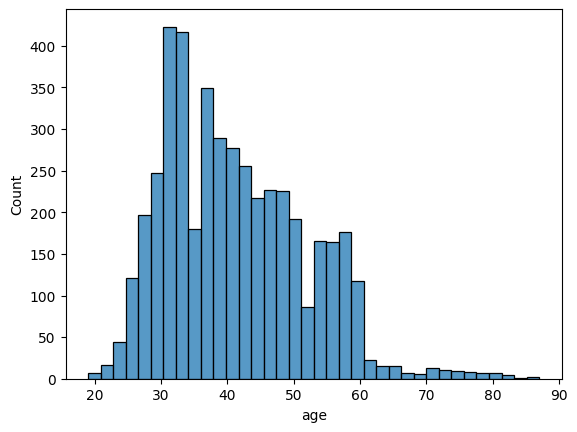

In [23]:
sns.histplot(df['age'])

In [24]:
df['age'].skew()

np.float64(0.6995014533559305)

In [25]:
df['age'].median()

39.0

In [26]:
df = df.drop(columns=['duration'])

In [27]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,4,211,3,other,no


In [28]:
df['y'].value_counts()

,count
y,
no,4000
yes,521


In [29]:
df['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.476001
yes,11.523999


In [30]:
(df == "unknown").sum()

,0
age,0
job,38
marital,0
education,187
default,0
balance,0
housing,0
loan,0
contact,1324
day,0


In [31]:
df["job"].value_counts()

,count
job,
management,969
blue-collar,946
technician,768
admin.,478
services,417
retired,230
self-employed,183
entrepreneur,168
unemployed,128


In [32]:
df["education"].value_counts()

,count
education,
secondary,2306
tertiary,1350
primary,678
unknown,187


In [33]:
df["contact"].value_counts()

,count
contact,
cellular,2896
unknown,1324
telephone,301


In [34]:
df["poutcome"].value_counts()

,count
poutcome,
unknown,3705
failure,490
other,197
success,129


In [35]:
df = df.replace("unknown", np.nan)
df = df.dropna()

In [36]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,1,330,1,failure,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,1,330,2,other,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,1,147,2,failure,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4492,32,technician,single,secondary,no,309,yes,yes,cellular,16,apr,1,234,3,failure,no
4504,42,blue-collar,single,secondary,no,1080,yes,yes,cellular,13,may,3,370,4,failure,yes
4514,38,blue-collar,married,secondary,no,1205,yes,no,cellular,20,apr,4,153,1,failure,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,4,211,3,other,no


In [37]:
X = df.drop("y", axis=1)
y = df["y"].map({"yes": 1, "no": 0})

In [38]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')
Numerical columns: Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object')


In [39]:
from sklearn.model_selection import train_test_split

In [40]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [42]:
preprocessor = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("scaler", StandardScaler(), numerical_cols)
])

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [44]:
model = pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

In [45]:
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')),
                                                 ('scaler', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='object'))])),
                ('classifier', LogisticRegression())])

In [46]:
y_pred = model.predict(x_test)

In [47]:
y_pred = model.predict(x_test)

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [49]:
y_prob = model.predict_proba(x_test)[:, 1]

In [50]:
print("First 10 y_pred values:", y_pred[:10])

First 10 y_pred values: [0 0 1 0 0 0 0 0 0 0]


In [51]:
print("First 10 y_prob values:", y_prob[:10])

First 10 y_prob values: [0.18638807 0.14497457 0.87281521 0.23479995 0.0976834  0.21151767
 0.07802657 0.07508053 0.17066912 0.03637572]


In [52]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7908496732026143


In [53]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.7617399901136925


In [54]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [55]:
y_pred = model.predict(x_test)

In [56]:
y_pred = model.predict_proba(x_test)[: ,1]

In [59]:
y_pred = model.predict(x_test)

In [62]:
print(y_pred[:20])
print(confusion_matrix(y_test, y_pred))

[0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0]
[[109  10]
 [ 22  12]]


In [63]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       119
           1       0.55      0.35      0.43        34

    accuracy                           0.79       153
   macro avg       0.69      0.63      0.65       153
weighted avg       0.77      0.79      0.77       153

